# Test for FBS scaling with LA

In [1]:
import numpy as np
import xarray as xr
import os
import sys

# main_dir = '/home/s2561233/Documents/Agrifood/ssr_local_authority'


from fbs_la_scaling import fbs_la_scaling

from agrifoodpy_data.land import ONS_LAD_MAY_2025_UK_BUC_1000 as la_land
from agrifoodpy_data.population import UK_ONS_MYE24UK as la_population
from agrifoodpy_data.food import FAOSTAT
from agrifoodpy_data.population import UK_ONS
from agrifoodpy_data.land import UKCEH_LC_1000 as land
from agrifoodpy_data.food import UK_LIVESTOCK_LAD as livestock_la_data

## Rescale

In [2]:
land_ids_dict = {
    'Highlands': np.where(la_land['LAD25NM'].values == 'Highland')[0][0],
    'City of London': np.where(la_land['LAD25NM'].values == 'City of London')[0][0],
    'South Gloucestershire':  np.where(la_land['LAD25NM'].values == 'South Gloucestershire')[0][0],
}

In [3]:
fbs = FAOSTAT.sel(Year=2019, Region=229).squeeze(drop=True)
population = UK_ONS.sel(Year=2022, Datatype='Total')

la_id = land_ids_dict['Highlands']

UK balance before scaling

<Axes: >

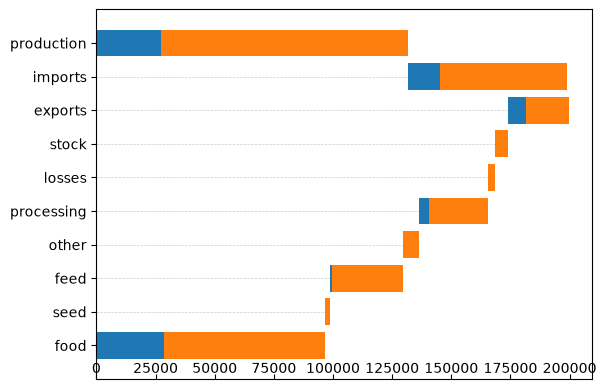

In [4]:
# plot UK fbs before scaling
food_uk = fbs.drop_vars(["Region", "Region_name", "Year"])
food_uk_origin = food_uk.fbs.group_sum("Item_origin")
food_uk_origin.fbs.plot_bars(show="Item_origin",
                             elements=["production", "imports"],
                             inverted_elements=["exports", "stock", "losses", "processing", "other", "feed", "seed", "food"])

In [5]:
# Sort fbs by Item to ensure consistent coordinate ordering
fbs_scaled, land_scaled, population_scaled = fbs_la_scaling(
    fbs,
    population,
    land,
    la_population,
    la_land,
    la_id,
    livestock_la_data
)

## Plot rescaled data

Highlands


<Axes: >

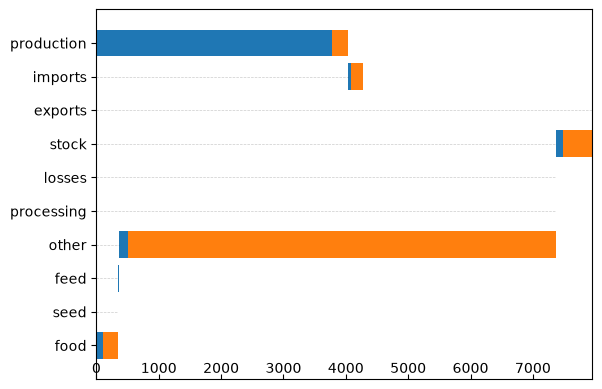

In [6]:
# plot land and plant production before and after the scaling
import matplotlib.pyplot as plt

# plot with fbs_scaled.plot_bars
food_la = fbs_scaled.drop_vars(["Region", "Region_name", "Year"])
food_la_origin = food_la.fbs.group_sum("Item_origin")

print('Highlands')
food_la_origin.fbs.plot_bars(show="Item_origin",
                             elements=["production", "imports"],
                             inverted_elements=["exports", "stock", "losses", "processing", "other", "feed", "seed", "food"])

Check that UK balance is preserved -- i.e., scaling doesn't chande the overall values

<Axes: >

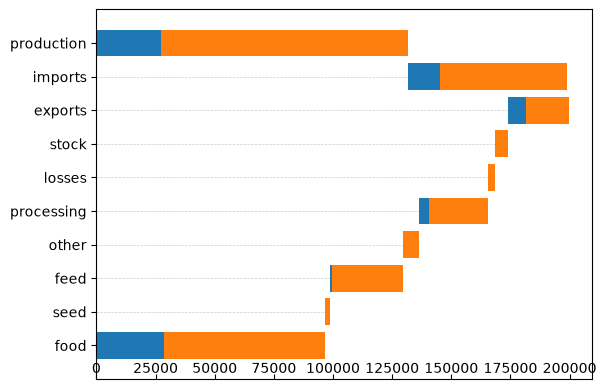

In [7]:
# plot UK FBS for comparison
food_uk = fbs.drop_vars(["Region", "Region_name", "Year"])
food_uk_origin = food_uk.fbs.group_sum("Item_origin")
food_uk_origin.fbs.plot_bars(show="Item_origin",
                             elements=["production", "imports"],
                             inverted_elements=["exports", "stock", "losses", "processing", "other", "feed", "seed", "food"])

## Check overall balance 
At UK level (summing over all LA quantities after scaling): production + import = consumption 

In [8]:
# get all LA ids
all_la_ids = np.array(la_land['ID'].values, dtype=str)

# get scaled quantities for all LAs
fbs_scaled_all = []
land_scaled_all = []
population_scaled_all = []

for i in range(len(all_la_ids)):
    fbs_scaled_i, land_scaled_i, population_scaled_i = fbs_la_scaling(
        fbs,
        population,
        land,
        la_population,
        la_land,
        all_la_ids[i],
        livestock_la_data
    )
    fbs_scaled_all.append(fbs_scaled_i.drop_vars(["Region", "Region_name", "Year"]))
    land_scaled_all.append(land_scaled_i)
    population_scaled_all.append(population_scaled_i)

In [9]:
# Build UK FBS as sum of all LA-scaled FBS (NaN-safe sum)
uk_from_las = xr.concat(fbs_scaled_all, dim="LA").sum(dim="LA", skipna=True)

# UK reference FBS (same structure as LA-scaled list entries)
uk_ref = fbs.drop_vars(["Region", "Region_name", "Year"])

# Align Item coordinate just in case
uk_from_las = uk_from_las.sel(Item=uk_ref.Item)

# Variables for balance check
inflow_vars = ["production", "imports"]
outflow_vars = ["exports", "stock", "losses", "processing", "other", "feed", "seed", "food"]

def total_vars(ds, var_list):
    return sum(float(ds[v].fillna(0).sum()) for v in var_list if v in ds)

# UK-level balance from summed LAs
la_in = total_vars(uk_from_las, inflow_vars)
la_out = total_vars(uk_from_las, outflow_vars)
la_gap = la_in - la_out

# UK-level balance from original UK FBS
uk_in = total_vars(uk_ref, inflow_vars)
uk_out = total_vars(uk_ref, outflow_vars)
uk_gap = uk_in - uk_out

print("=== Balance check ===")
print(f"Summed LA FBS: inflow={la_in:,.3f}, outflow={la_out:,.3f}, gap={la_gap:,.3f}")
print(f"UK reference : inflow={uk_in:,.3f}, outflow={uk_out:,.3f}, gap={uk_gap:,.3f}")
print(f"Gap difference (LA - UK): {la_gap - uk_gap:,.6f}")

print("\n=== Variable total comparison (Summed LA vs UK reference) ===")
all_vars = [v for v in uk_ref.data_vars if v in uk_from_las.data_vars]
for v in all_vars:
    la_total = float(uk_from_las[v].fillna(0).sum())
    uk_total = float(uk_ref[v].fillna(0).sum())
    diff = la_total - uk_total
    print(f"{v:>10s}: LA_sum={la_total:,.3f} | UK={uk_total:,.3f} | diff={diff:,.3f}")

=== Balance check ===
Summed LA FBS: inflow=185,118.952, outflow=2,800,673.815, gap=-2,615,554.863
UK reference : inflow=199,057.953, outflow=199,649.420, gap=-591.467
Gap difference (LA - UK): -2,614,963.396226

=== Variable total comparison (Summed LA vs UK reference) ===
     stock: LA_sum=170,139.360 | UK=5,327.000 | diff=164,812.360
    losses: LA_sum=0.000 | UK=3,007.000 | diff=-3,007.000
processing: LA_sum=0.000 | UK=29,103.000 | diff=-29,103.000
      food: LA_sum=97,873.649 | UK=96,666.211 | diff=1,207.438
     other: LA_sum=2,530,245.250 | UK=7,008.990 | diff=2,523,236.260
  residual: LA_sum=0.000 | UK=-592.000 | diff=592.000
   tourist: LA_sum=0.000 | UK=0.000 | diff=0.000
  domestic: LA_sum=60,662,584.000 | UK=168,040.391 | diff=60,494,543.609
production: LA_sum=117,045.125 | UK=131,823.938 | diff=-14,778.812
      feed: LA_sum=805.387 | UK=30,920.648 | diff=-30,115.261
      seed: LA_sum=1,610.169 | UK=1,926.000 | diff=-315.831
   imports: LA_sum=68,073.827 | UK=67,234.016

<Axes: >

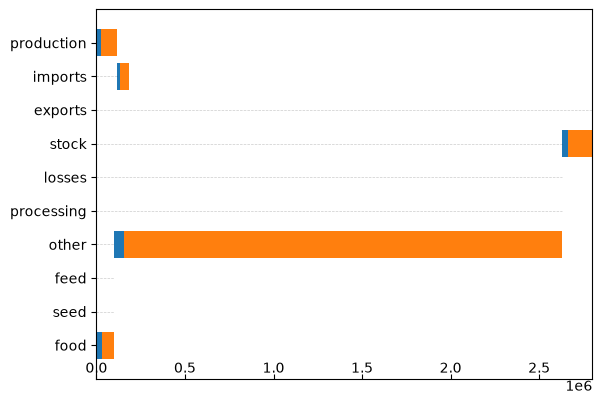

In [14]:
# plot uk fbs obtained from all LAs
food_la_origin_all = uk_from_las.fbs.group_sum("Item_origin")
food_la_origin_all.fbs.plot_bars(show="Item_origin",
                                 elements=["production", "imports"],
                                 inverted_elements=["exports", "stock", "losses", "processing", "other", "feed", "seed", "food"])    